In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import hvplot.xarray
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from scipy.optimize import curve_fit

[ 1.08724104e-13 -5.76010740e-13 -2.00298037e-09  8.44593881e-09
  5.00664279e-06 -2.77843394e-05 -1.32053852e-01  5.84575839e-03]


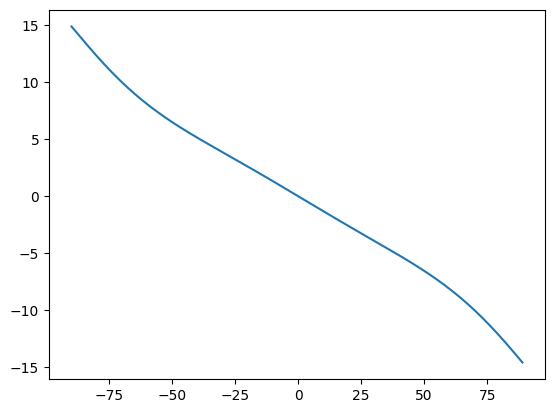

In [3]:
calib_dir = "C:\\Users\\Ralph Group\\Documents\\Github\\SagnacOperatingSys\\sagnac_control\\calibrations\\old_calibrations\\pre20260430\\"
radial_polar_coeff= np.loadtxt(calib_dir + 'sagnac_radial_polar_calib.csv', delimiter=',')
radial_polar_calib = np.poly1d(radial_polar_coeff)
theta = np.arange(-90, 90, 1)
plt.plot(theta, radial_polar_calib(theta))
print(radial_polar_coeff)

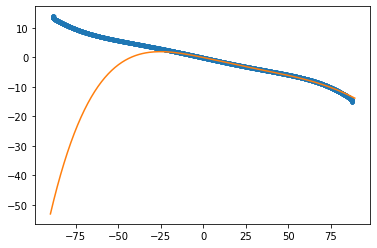

In [8]:
measured = pd.read_csv('test_daedalus_radialPolar_calib_A000.0_2025-06-26_2.csv', comment = '#', index_col = 'theta')
ds = xr.Dataset(measured)
ds = ds.where(ds.R < 14, drop=True)
plt.plot(ds['theta'], ds['R'],'.')
plt.plot(theta, radial_polar_calib(theta))

[-1.56324082e-09  1.85886540e-08  7.75096817e-06 -6.37722672e-05
 -1.25919448e-01  1.06698154e-01]


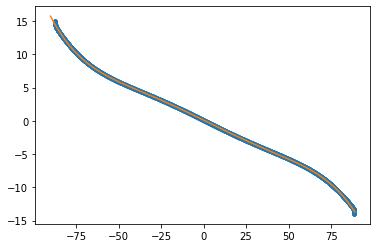

In [9]:
theta = np.arange(-90, 90, 1)
#plt.plot(theta, radial_polar_calib(theta))
plt.plot(-ds['theta'], -ds['R'], '.')

radial_polar_coeff_new = np.polyfit(-ds['theta'], -ds['R'], 5)
print(radial_polar_coeff_new)
radial_polar_calib_new = np.poly1d(radial_polar_coeff_new)
plt.plot(theta, radial_polar_calib_new(theta))

[ 1.56324082e-09 -1.85886540e-08 -7.75096817e-06  6.37722672e-05
  1.25919448e-01 -1.06698154e-01]


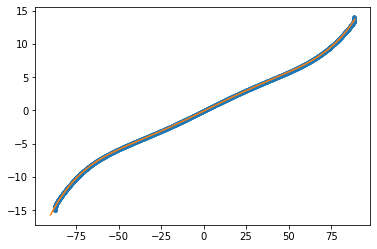

In [14]:
theta = np.arange(-90, 90, 1)
#plt.plot(theta, radial_polar_calib(theta))
plt.plot(-ds['theta'], ds['R'], '.')

radial_polar_coeff_new = np.polyfit(-ds['theta'], ds['R'], 5)
print(radial_polar_coeff_new)
radial_polar_calib_new = np.poly1d(radial_polar_coeff_new)
plt.plot(theta, radial_polar_calib_new(theta))
#save to radial_polar (radial_polar)